In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
FIFA_URL = "https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics"
FBREF_URL = "https://fbref.com/en/comps/1/2026/stats/2026-World-Cup-Stats"
STATS_DONT_LIE_URL = "https://www.thestatsdontlie.com/football/world-cup-2026/"

print("FIFA:")
print(FIFA_URL)

print("\nFBref:")
print(FBREF_URL)

print("\nThe Stats Don't Lie:")
print(STATS_DONT_LIE_URL)

FIFA:
https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics

FBref:
https://fbref.com/en/comps/1/2026/stats/2026-World-Cup-Stats

The Stats Don't Lie:
https://www.thestatsdontlie.com/football/world-cup-2026/


In [5]:
FILE_NAME = "FIFA_World_Cup_2026_Task4_Discipline_Data.csv"

df = pd.read_csv(FILE_NAME)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head(10))

Dataset loaded successfully.
Shape: (48, 3)


,Team,MatchesPlayed,YellowCards
0,Algeria,4,3
1,Argentina,8,15
2,Australia,4,5
3,Austria,4,5
4,Belgium,6,6
5,Bosnia–Herzegovina,4,7
6,Brazil,5,8
7,Cabo Verde,4,5
8,Canada,5,11
9,Colombia,5,8


In [6]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

Column names:
['Team', 'MatchesPlayed', 'YellowCards']

Data types:
Team             object
MatchesPlayed     int64
YellowCards       int64
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Team           48 non-null     object
 1   MatchesPlayed  48 non-null     int64 
 2   YellowCards    48 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


In [7]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate team rows:")
print(df["Team"].duplicated().sum())

Missing values:
Team             0
MatchesPlayed    0
YellowCards      0
dtype: int64

Duplicate team rows:
0


In [8]:
df = df.copy()

df = df.dropna(
    subset=["Team", "MatchesPlayed", "YellowCards"]
)

df["Team"] = (
    df["Team"]
    .astype(str)
    .str.strip()
)

df["MatchesPlayed"] = pd.to_numeric(
    df["MatchesPlayed"],
    errors="coerce"
)

df["YellowCards"] = pd.to_numeric(
    df["YellowCards"],
    errors="coerce"
)

df = df.dropna(
    subset=["MatchesPlayed", "YellowCards"]
)

df = df[
    (df["MatchesPlayed"] > 0) &
    (df["YellowCards"] >= 0)
]

df = df.drop_duplicates(
    subset="Team",
    keep="first"
)

df = df.reset_index(drop=True)

print("Cleaned dataset shape:", df.shape)
display(df.head(10))

Cleaned dataset shape: (48, 3)


,Team,MatchesPlayed,YellowCards
0,Algeria,4,3
1,Argentina,8,15
2,Australia,4,5
3,Austria,4,5
4,Belgium,6,6
5,Bosnia–Herzegovina,4,7
6,Brazil,5,8
7,Cabo Verde,4,5
8,Canada,5,11
9,Colombia,5,8


In [9]:
number_of_teams = df["Team"].nunique()

print("Number of unique teams:", number_of_teams)

if number_of_teams == 48:
    print("Validation passed: all 48 World Cup teams are present.")
else:
    print("WARNING: expected 48 teams.")

Number of unique teams: 48
Validation passed: all 48 World Cup teams are present.


In [10]:
df["Stage"] = np.where(
    df["MatchesPlayed"] >= 4,
    "Reached knockout stage",
    "Eliminated in group stage"
)

print(df["Stage"].value_counts())

display(
    df[
        ["Team", "MatchesPlayed", "Stage"]
    ].head(10)
)

Stage
Reached knockout stage       32
Eliminated in group stage    16
Name: count, dtype: int64


,Team,MatchesPlayed,Stage
0,Algeria,4,Reached knockout stage
1,Argentina,8,Reached knockout stage
2,Australia,4,Reached knockout stage
3,Austria,4,Reached knockout stage
4,Belgium,6,Reached knockout stage
5,Bosnia–Herzegovina,4,Reached knockout stage
6,Brazil,5,Reached knockout stage
7,Cabo Verde,4,Reached knockout stage
8,Canada,5,Reached knockout stage
9,Colombia,5,Reached knockout stage


In [11]:
stage_counts = df["Stage"].value_counts()

n_knockout = stage_counts.get(
    "Reached knockout stage",
    0
)

n_group = stage_counts.get(
    "Eliminated in group stage",
    0
)

print("Reached knockout stage:", n_knockout)
print("Eliminated in group stage:", n_group)

if n_knockout == 32 and n_group == 16:
    print("Stage classification passed.")
else:
    print("Please check the stage classification.")

Reached knockout stage: 32
Eliminated in group stage: 16
Stage classification passed.


In [12]:
df["YellowCardsPerMatch"] = (
    df["YellowCards"] /
    df["MatchesPlayed"]
)

display(
    df[
        [
            "Team",
            "MatchesPlayed",
            "YellowCards",
            "Stage",
            "YellowCardsPerMatch"
        ]
    ]
    .head(10)
    .round(3)
)

,Team,MatchesPlayed,YellowCards,Stage,YellowCardsPerMatch
0,Algeria,4,3,Reached knockout stage,0.750
1,Argentina,8,15,Reached knockout stage,1.875
2,Australia,4,5,Reached knockout stage,1.250
3,Austria,4,5,Reached knockout stage,1.250
4,Belgium,6,6,Reached knockout stage,1.000
5,Bosnia–Herzegovina,4,7,Reached knockout stage,1.750
6,Brazil,5,8,Reached knockout stage,1.600
7,Cabo Verde,4,5,Reached knockout stage,1.250
8,Canada,5,11,Reached knockout stage,2.200
9,Colombia,5,8,Reached knockout stage,1.600


In [13]:
knockout = df.loc[
    df["Stage"] == "Reached knockout stage",
    "YellowCardsPerMatch"
]

group_stage = df.loc[
    df["Stage"] == "Eliminated in group stage",
    "YellowCardsPerMatch"
]

print("Knockout-stage observations:", len(knockout))
print("Group-stage eliminated observations:", len(group_stage))

Knockout-stage observations: 32
Group-stage eliminated observations: 16


In [14]:
descriptive = (
    df.groupby("Stage")["YellowCardsPerMatch"]
      .agg([
          "count",
          "mean",
          "median",
          "std",
          "min",
          "max"
      ])
      .round(3)
)

display(descriptive)

,count,mean,median,std,min,max
Stage,,,,,,
Eliminated in group stage,16,1.438,1.333,0.605,0.333,2.333
Reached knockout stage,32,1.268,1.250,0.466,0.500,2.400


In [15]:
summary_rows = []

for stage_name, values in df.groupby("Stage")["YellowCardsPerMatch"]:

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    summary_rows.append({
        "Stage": stage_name,
        "n": len(values),
        "Mean": values.mean(),
        "Median": values.median(),
        "SD": values.std(ddof=1),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,
        "Minimum": values.min(),
        "Maximum": values.max()
    })

summary_table = pd.DataFrame(summary_rows)

display(summary_table.round(3))

,Stage,n,Mean,Median,SD,Q1,Q3,IQR,Minimum,Maximum
0,Eliminated in group stage,16,1.438,1.333,0.605,1.333,1.750,0.417,0.333,2.333
1,Reached knockout stage,32,1.268,1.250,0.466,0.950,1.525,0.575,0.500,2.400


In [16]:
mean_knockout = knockout.mean()
mean_group = group_stage.mean()

mean_difference = (
    mean_knockout -
    mean_group
)

print(f"Knockout-stage mean = {mean_knockout:.3f}")
print(f"Group-stage eliminated mean = {mean_group:.3f}")
print(f"Difference (KO - GS) = {mean_difference:.3f}")

Knockout-stage mean = 1.268
Group-stage eliminated mean = 1.438
Difference (KO - GS) = -0.170


In [17]:
def mean_confidence_interval(values, confidence=0.95):

    values = pd.Series(values).dropna()

    n = len(values)
    sample_mean = values.mean()
    sample_sd = values.std(ddof=1)

    standard_error = (
        sample_sd /
        np.sqrt(n)
    )

    alpha_ci = 1 - confidence

    t_critical = stats.t.ppf(
        1 - alpha_ci / 2,
        df=n - 1
    )

    margin_error = (
        t_critical *
        standard_error
    )

    lower = (
        sample_mean -
        margin_error
    )

    upper = (
        sample_mean +
        margin_error
    )

    return {
        "n": n,
        "mean": sample_mean,
        "sd": sample_sd,
        "se": standard_error,
        "lower": lower,
        "upper": upper
    }

In [18]:
ci_knockout = mean_confidence_interval(knockout)
ci_group = mean_confidence_interval(group_stage)

print("Reached knockout stage")
print(f"Mean = {ci_knockout['mean']:.3f}")
print(
    f"95% CI = "
    f"({ci_knockout['lower']:.3f}, "
    f"{ci_knockout['upper']:.3f})"
)

print("\nEliminated in group stage")
print(f"Mean = {ci_group['mean']:.3f}")
print(
    f"95% CI = "
    f"({ci_group['lower']:.3f}, "
    f"{ci_group['upper']:.3f})"
)

Reached knockout stage
Mean = 1.268
95% CI = (1.100, 1.436)

Eliminated in group stage
Mean = 1.438
95% CI = (1.115, 1.760)


In [19]:
n1 = len(knockout)
n2 = len(group_stage)

mean1 = knockout.mean()
mean2 = group_stage.mean()

var1 = knockout.var(ddof=1)
var2 = group_stage.var(ddof=1)

difference = (
    mean1 -
    mean2
)

se_difference = np.sqrt(
    (var1 / n1) +
    (var2 / n2)
)

welch_df = (
    ((var1 / n1) + (var2 / n2)) ** 2
) / (
    ((var1 / n1) ** 2 / (n1 - 1)) +
    ((var2 / n2) ** 2 / (n2 - 1))
)

t_critical_difference = stats.t.ppf(
    0.975,
    df=welch_df
)

difference_lower = (
    difference -
    t_critical_difference *
    se_difference
)

difference_upper = (
    difference +
    t_critical_difference *
    se_difference
)

print(f"Mean difference = {difference:.3f}")
print(
    f"95% CI for difference = "
    f"({difference_lower:.3f}, "
    f"{difference_upper:.3f})"
)
print(f"Welch degrees of freedom = {welch_df:.3f}")

Mean difference = -0.170
95% CI for difference = (-0.525, 0.186)
Welch degrees of freedom = 24.178


In [20]:
alpha = 0.05

print("H0: mu_KO >= mu_GS")
print("H1: mu_KO < mu_GS")
print("Significance level =", alpha)

H0: mu_KO >= mu_GS
H1: mu_KO < mu_GS
Significance level = 0.05


In [21]:
t_statistic, p_value = stats.ttest_ind(
    knockout,
    group_stage,
    equal_var=False,
    alternative="less"
)

print("Welch t-test results")
print(f"t-statistic = {t_statistic:.4f}")
print(f"p-value = {p_value:.4f}")
print(f"alpha = {alpha}")

Welch t-test results
t-statistic = -0.9842
p-value = 0.1674
alpha = 0.05


In [22]:
if p_value < alpha:

    decision = "Reject H0"

    conclusion = (
        "There is sufficient statistical evidence to conclude "
        "that teams reaching the knockout stage received fewer "
        "yellow cards per match, on average, than teams eliminated "
        "in the group stage."
    )

else:

    decision = "Do not reject H0"

    conclusion = (
        "There is insufficient statistical evidence to conclude "
        "that teams reaching the knockout stage received fewer "
        "yellow cards per match, on average, than teams eliminated "
        "in the group stage."
    )

print("Decision:", decision)

print("\nConclusion:")
print(conclusion)


Decision: Do not reject H0

Conclusion:
There is insufficient statistical evidence to conclude that teams reaching the knockout stage received fewer yellow cards per match, on average, than teams eliminated in the group stage.


In [23]:
pooled_sd = np.sqrt(
    (
        (n1 - 1) * var1 +
        (n2 - 1) * var2
    )
    /
    (n1 + n2 - 2)
)

cohens_d = (
    difference /
    pooled_sd
)

print(f"Cohen's d = {cohens_d:.3f}")

print(
    "Approximate interpretation: "
    "|0.2| small, |0.5| medium, |0.8| large."
)


Cohen's d = -0.329
Approximate interpretation: |0.2| small, |0.5| medium, |0.8| large.


In [24]:
shapiro_knockout = stats.shapiro(knockout)
shapiro_group = stats.shapiro(group_stage)

print(
    f"Knockout group: "
    f"W = {shapiro_knockout.statistic:.4f}, "
    f"p = {shapiro_knockout.pvalue:.4f}"
)

print(
    f"Group-stage eliminated: "
    f"W = {shapiro_group.statistic:.4f}, "
    f"p = {shapiro_group.pvalue:.4f}"
)


Knockout group: W = 0.9520, p = 0.1642
Group-stage eliminated: W = 0.9104, p = 0.1180


In [25]:
levene_stat, levene_p = stats.levene(
    knockout,
    group_stage
)

print(f"Levene statistic = {levene_stat:.4f}")
print(f"Levene p-value = {levene_p:.4f}")

Levene statistic = 0.5219
Levene p-value = 0.4737


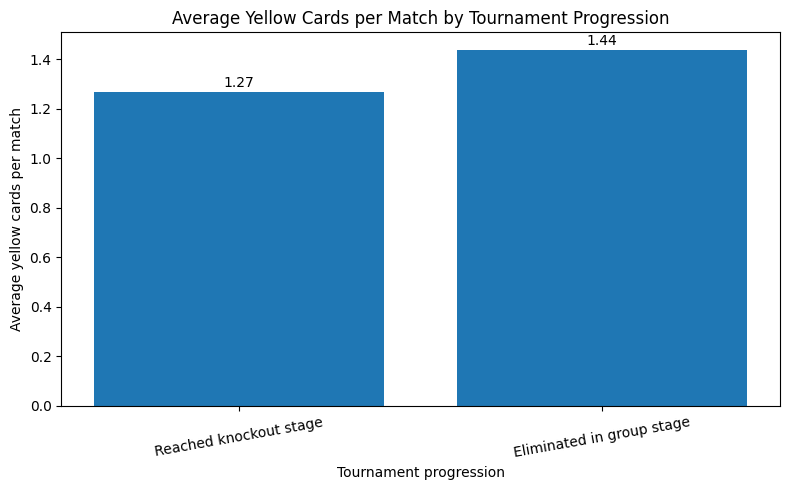

In [26]:
labels = [
    "Reached knockout stage",
    "Eliminated in group stage"
]

means = [
    mean_knockout,
    mean_group
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    labels,
    means
)

plt.title(
    "Average Yellow Cards per Match "
    "by Tournament Progression"
)

plt.xlabel("Tournament progression")
plt.ylabel("Average yellow cards per match")

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.2f}",
        ha="center"
    )

plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

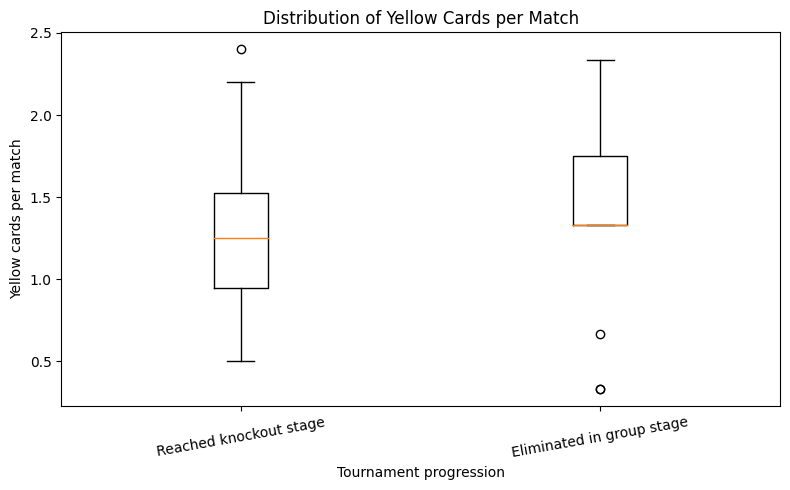

In [27]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        knockout,
        group_stage
    ],
    labels=[
        "Reached knockout stage",
        "Eliminated in group stage"
    ]
)

plt.title(
    "Distribution of Yellow Cards per Match"
)

plt.xlabel("Tournament progression")
plt.ylabel("Yellow cards per match")

plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

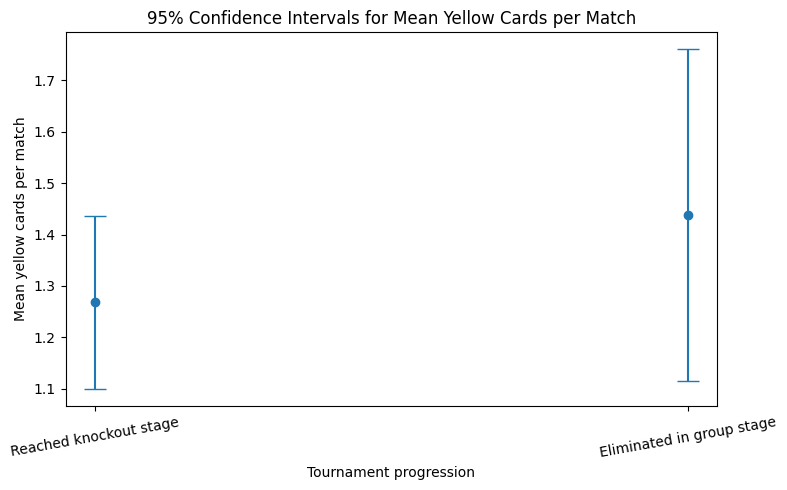

In [28]:
group_names = [
    "Reached knockout stage",
    "Eliminated in group stage"
]

means = np.array([
    ci_knockout["mean"],
    ci_group["mean"]
])

lower_errors = np.array([
    ci_knockout["mean"] - ci_knockout["lower"],
    ci_group["mean"] - ci_group["lower"]
])

upper_errors = np.array([
    ci_knockout["upper"] - ci_knockout["mean"],
    ci_group["upper"] - ci_group["mean"]
])

errors = np.vstack([
    lower_errors,
    upper_errors
])

plt.figure(figsize=(8, 5))

plt.errorbar(
    group_names,
    means,
    yerr=errors,
    fmt="o",
    capsize=8
)

plt.title(
    "95% Confidence Intervals for "
    "Mean Yellow Cards per Match"
)

plt.xlabel("Tournament progression")
plt.ylabel("Mean yellow cards per match")

plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

In [29]:
team_results = (
    df[
        [
            "Team",
            "MatchesPlayed",
            "YellowCards",
            "Stage",
            "YellowCardsPerMatch"
        ]
    ]
    .sort_values(
        ["Stage", "YellowCardsPerMatch"]
    )
    .reset_index(drop=True)
)

display(
    team_results.round(3)
)

,Team,MatchesPlayed,YellowCards,Stage,YellowCardsPerMatch
0,Czechia,3,1,Eliminated in group stage,0.333
1,Tunisia,3,1,Eliminated in group stage,0.333
2,Türkiye,3,2,Eliminated in group stage,0.667
3,Iraq,3,4,Eliminated in group stage,1.333
4,Jordan,3,4,Eliminated in group stage,1.333
5,Korea Republic,3,4,Eliminated in group stage,1.333
6,New Zealand,3,4,Eliminated in group stage,1.333
7,Qatar,3,4,Eliminated in group stage,1.333
8,Uzbekistan,3,4,Eliminated in group stage,1.333
9,Panama,3,5,Eliminated in group stage,1.667


In [30]:
results_table = pd.DataFrame({
    "Measure": [
        "Knockout-stage teams (n)",
        "Group-stage eliminated teams (n)",
        "Knockout mean yellow cards/match",
        "Group-stage mean yellow cards/match",
        "Mean difference (KO - GS)",
        "95% CI difference lower",
        "95% CI difference upper",
        "Welch t-statistic",
        "Welch degrees of freedom",
        "One-sided p-value",
        "Cohen's d"
    ],

    "Result": [
        n1,
        n2,
        mean1,
        mean2,
        difference,
        difference_lower,
        difference_upper,
        t_statistic,
        welch_df,
        p_value,
        cohens_d
    ]
})

display(
    results_table.round(4)
)

,Measure,Result
0,Knockout-stage teams (n),32.0000
1,Group-stage eliminated teams (n),16.0000
2,Knockout mean yellow cards/match,1.2680
3,Group-stage mean yellow cards/match,1.4375
4,Mean difference (KO - GS),-0.1695
5,95% CI difference lower,-0.5249
6,95% CI difference upper,0.1858
7,Welch t-statistic,-0.9842
8,Welch degrees of freedom,24.1778
9,One-sided p-value,0.1674


In [31]:
df.to_csv(
    "FIFA_World_Cup_2026_Task4_Discipline_Cleaned.csv",
    index=False
)

summary_table.to_csv(
    "FIFA_World_Cup_2026_Task4_Discipline_Summary.csv",
    index=False
)

results_table.to_csv(
    "FIFA_World_Cup_2026_Task4_Discipline_Results.csv",
    index=False
)

print("All output files saved successfully.")

All output files saved successfully.


In [32]:
print("=" * 75)
print("FINAL INTERPRETATION")
print("=" * 75)

print(
    f"\nTeams that reached the knockout stage received "
    f"an average of {mean_knockout:.2f} yellow cards per match."
)

print(
    f"Teams eliminated in the group stage received "
    f"an average of {mean_group:.2f} yellow cards per match."
)

print(
    f"The observed mean difference was "
    f"{mean_difference:.2f} yellow cards per match."
)

print(
    f"\nThe one-sided Welch two-sample t-test produced "
    f"t = {t_statistic:.2f} and p = {p_value:.3f}."
)

if p_value < alpha:
    print(
        "\nBecause p < 0.05, the null hypothesis is rejected."
    )
else:
    print(
        "\nBecause p > 0.05, the null hypothesis is not rejected."
    )

print("\n" + conclusion)

print(
    "\nThe analysis identifies an association only. "
    "It does not prove that receiving fewer yellow cards "
    "causes a team to progress further in the tournament."
)

FINAL INTERPRETATION

Teams that reached the knockout stage received an average of 1.27 yellow cards per match.
Teams eliminated in the group stage received an average of 1.44 yellow cards per match.
The observed mean difference was -0.17 yellow cards per match.

The one-sided Welch two-sample t-test produced t = -0.98 and p = 0.167.

Because p > 0.05, the null hypothesis is not rejected.

There is insufficient statistical evidence to conclude that teams reaching the knockout stage received fewer yellow cards per match, on average, than teams eliminated in the group stage.

The analysis identifies an association only. It does not prove that receiving fewer yellow cards causes a team to progress further in the tournament.
